### Importing Libraries

In [53]:
%run eda_helper.py

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import eda_helper
from sklearn.ensemble import IsolationForest
import os

## 2.Read the training data

In [3]:
PROJECT_DIR = r"C:\Users\Naruto\Desktop\generative_ai\PROJECTS\flight_price_prediction"
DATA_DIR = "data"

In [4]:
os.path.join(PROJECT_DIR,DATA_DIR)

'C:\\Users\\Naruto\\Desktop\\generative_ai\\PROJECTS\\flight_price_prediction\\data'

In [5]:
def get_data(name):
	file_name = f"{name}.csv"
	file_path = os.path.join(PROJECT_DIR, DATA_DIR, file_name)
	return pd.read_csv(file_path)

In [6]:
train = get_data("train")
train.head(5)

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-18,Banglore,New Delhi,16:55:00,23:00:00,365,1.0,No Info,13555
1,Indigo,2019-06-09,Banglore,Delhi,08:30:00,11:20:00,170,0.0,No Info,4823
2,Indigo,2019-05-18,Kolkata,Banglore,04:40:00,07:15:00,155,0.0,No Info,4804
3,Jet Airways,2019-05-18,Kolkata,Banglore,14:05:00,19:50:00,345,1.0,No Info,14781
4,Spicejet,2019-05-09,Kolkata,Banglore,17:10:00,19:40:00,150,0.0,No Info,3873


In [7]:
train.dtypes

airline             object
date_of_journey     object
source              object
destination         object
dep_time            object
arrival_time        object
duration             int64
total_stops        float64
additional_info     object
price                int64
dtype: object

In [8]:
train = train.assign(**{
    col:pd.to_datetime(train.loc[:,col], dayfirst=True,errors='coerce')
    for col in ["date_of_journey", "dep_time", "arrival_time"]
})
train.dtypes

C:\Users\Naruto\AppData\Local\Temp\ipykernel_32408\2907343377.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  col:pd.to_datetime(train.loc[:,col], dayfirst=True,errors='coerce')
C:\Users\Naruto\AppData\Local\Temp\ipykernel_32408\2907343377.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  col:pd.to_datetime(train.loc[:,col], dayfirst=True,errors='coerce')
C:\Users\Naruto\AppData\Local\Temp\ipykernel_32408\2907343377.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  col:pd.to_datetime(train.loc[:,col], dayfirst=True,errors='coerce')


airline                    object
date_of_journey    datetime64[ns]
source                     object
destination                object
dep_time           datetime64[ns]
arrival_time       datetime64[ns]
duration                    int64
total_stops               float64
additional_info            object
price                       int64
dtype: object

#### 3. High level info of data

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   airline          640 non-null    object        
 1   date_of_journey  640 non-null    datetime64[ns]
 2   source           640 non-null    object        
 3   destination      640 non-null    object        
 4   dep_time         640 non-null    datetime64[ns]
 5   arrival_time     640 non-null    datetime64[ns]
 6   duration         640 non-null    int64         
 7   total_stops      640 non-null    float64       
 8   additional_info  640 non-null    object        
 9   price            640 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(4)
memory usage: 50.1+ KB


In [10]:
train.describe(include="number")

,duration,total_stops,price
count,640.000000,640.00000,640.000000
mean,631.992188,0.80625,8998.690625
std,513.307778,0.68744,4715.976957
min,75.000000,0.00000,1965.000000
25%,170.000000,0.00000,5212.250000
50%,470.000000,1.00000,8016.000000
75%,920.000000,1.00000,12373.000000
max,2295.000000,3.00000,54826.000000


In [11]:
(
    train.assign(total_stops=train["total_stops"].astype(object))
    .describe(include="O")
)

,airline,source,destination,total_stops,additional_info
count,640,640,640,640.0,640
unique,8,5,6,4.0,4
top,Jet Airways,Delhi,Cochin,1.0,No Info
freq,216,274,274,332.0,519


In [12]:
train.describe(include="O")

,airline,source,destination,additional_info
count,640,640,640,640
unique,8,5,6,4
top,Jet Airways,Delhi,Cochin,No Info
freq,216,274,274,519


### 4. High-level analysis of missing value

In [13]:
missing_info(train)

,count,percentage
variable,,


In [14]:
train[train['total_stops'].isnull()]

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price


### 5. High Level Analysis of Outlier

In [20]:
forest = IsolationForest(n_estimators=10, random_state=42)

In [24]:
(
    train
    .assign(outlier=forest.fit_predict(
        train
        .drop(columns="price")
        .select_dtypes(include="number")
    ))
    .query("outlier == -1")
    # .duration
    # .describe()
)

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price,outlier
7,Indigo,2019-05-18,Chennai,Kolkata,2024-06-04 19:35:00,2024-06-04 21:55:00,140,0.0,No Info,3597,-1
10,Multiple Carriers,2019-03-21,Delhi,Cochin,2024-06-04 13:15:00,2024-06-04 21:20:00,485,2.0,No Info,6653,-1
11,Jet Airways,2019-06-12,Delhi,Cochin,2024-06-04 09:35:00,2024-06-04 04:25:00,1130,2.0,No Info,13292,-1
15,Jet Airways,2019-06-09,Delhi,Cochin,2024-06-04 17:30:00,2024-06-04 12:35:00,1145,1.0,In-flight meal not included,10262,-1
17,Vistara,2019-05-24,Kolkata,Banglore,2024-06-04 20:20:00,2024-06-04 20:20:00,1440,1.0,No Info,9345,-1
...,...,...,...,...,...,...,...,...,...,...,...
632,Air India,2019-03-27,Delhi,Cochin,2024-06-04 16:40:00,2024-06-04 19:15:00,1595,2.0,No Info,8656,-1
633,Air India,2019-06-09,Delhi,Cochin,2024-06-04 09:45:00,2024-06-04 09:25:00,1420,1.0,No Info,7690,-1
637,Jet Airways,2019-06-12,Delhi,Cochin,2024-06-04 20:55:00,2024-06-04 19:00:00,1325,1.0,In-flight meal not included,10262,-1
638,Jet Airways,2019-03-21,Delhi,Cochin,2024-06-04 05:30:00,2024-06-04 18:50:00,2240,2.0,In-flight meal not included,9328,-1


### 6. Pair plot

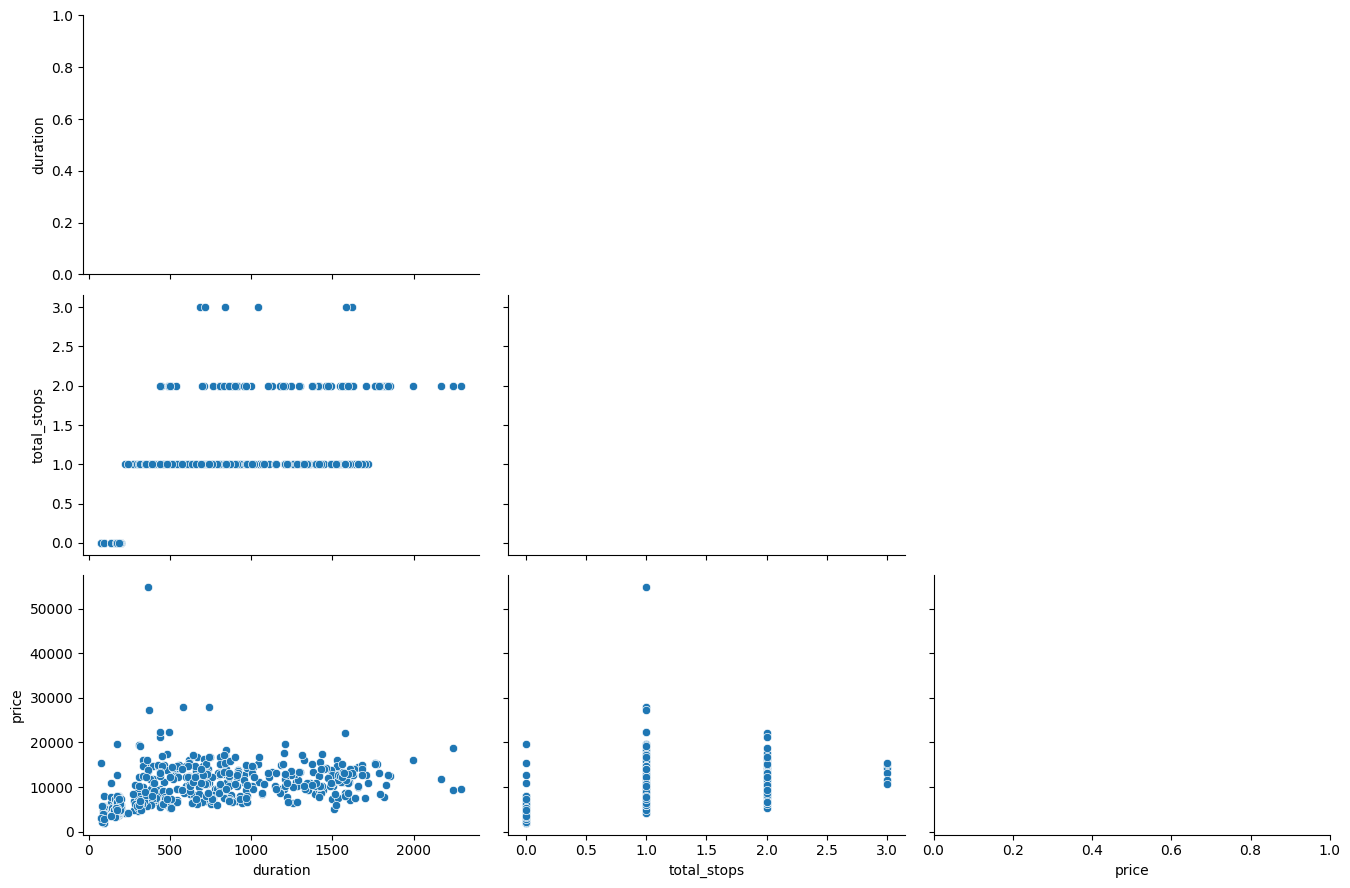

In [31]:
eda_helper.pair_plots(train)

### 7. Correlation Analysis

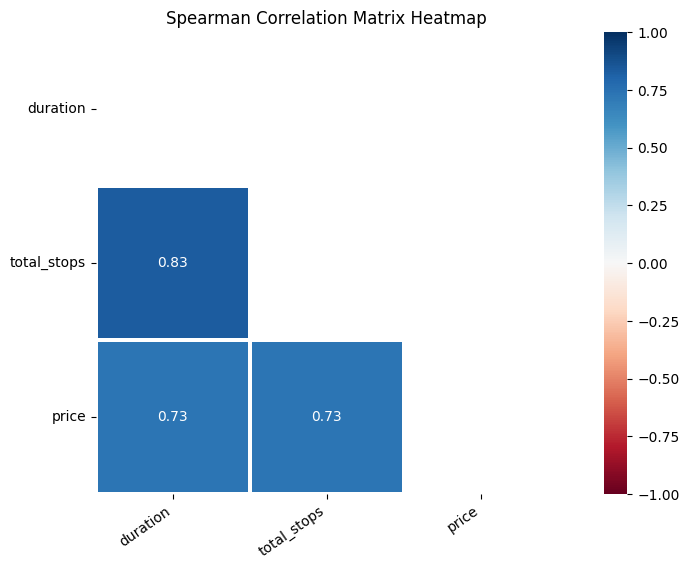

In [32]:
eda_helper.correlation_heatmap(train)

In [33]:
train.corr(method="spearman",numeric_only=True)

,duration,total_stops,price
duration,1.000000,0.829349,0.728005
total_stops,0.829349,1.000000,0.727091
price,0.728005,0.727091,1.000000


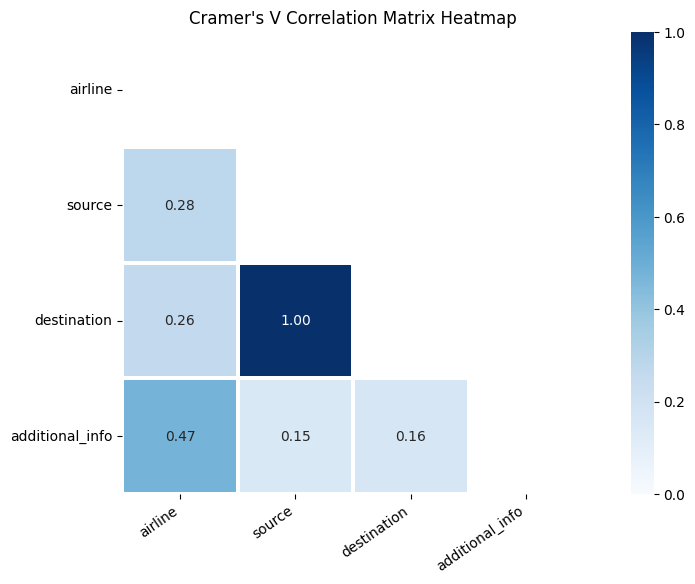

In [34]:
eda_helper.cramersV_heatmap(train)

### 8. Detailed Analysis

In [35]:
train.columns

Index(['airline', 'date_of_journey', 'source', 'destination', 'dep_time',
       'arrival_time', 'duration', 'total_stops', 'additional_info', 'price'],
      dtype='object')

#### 8.1 airline

In [37]:
eda_helper.cat_summary(train, "airline")

0      Jet Airways
1           Indigo
2           Indigo
3      Jet Airways
4         Spicejet
          ...     
635         Indigo
636    Jet Airways
637    Jet Airways
638    Jet Airways
639    Jet Airways
Name: airline, Length: 640, dtype: object

Data Type      : object
Cardinality    : 8 categories
Missing Data   : 0 rows (0.00 %)
Available Data : 640 / 640 rows


,
count,640
unique,8
top,Jet Airways
freq,216


,count,percentage
category,,
Jet Airways,216,0.337500
Indigo,132,0.206250
Air India,116,0.181250
Multiple Carriers,73,0.114062
Spicejet,46,0.071875
Vistara,26,0.040625
Air Asia,20,0.031250
Goair,11,0.017188


ValueError: Cardinality of airline is 8. K must be less than 8.

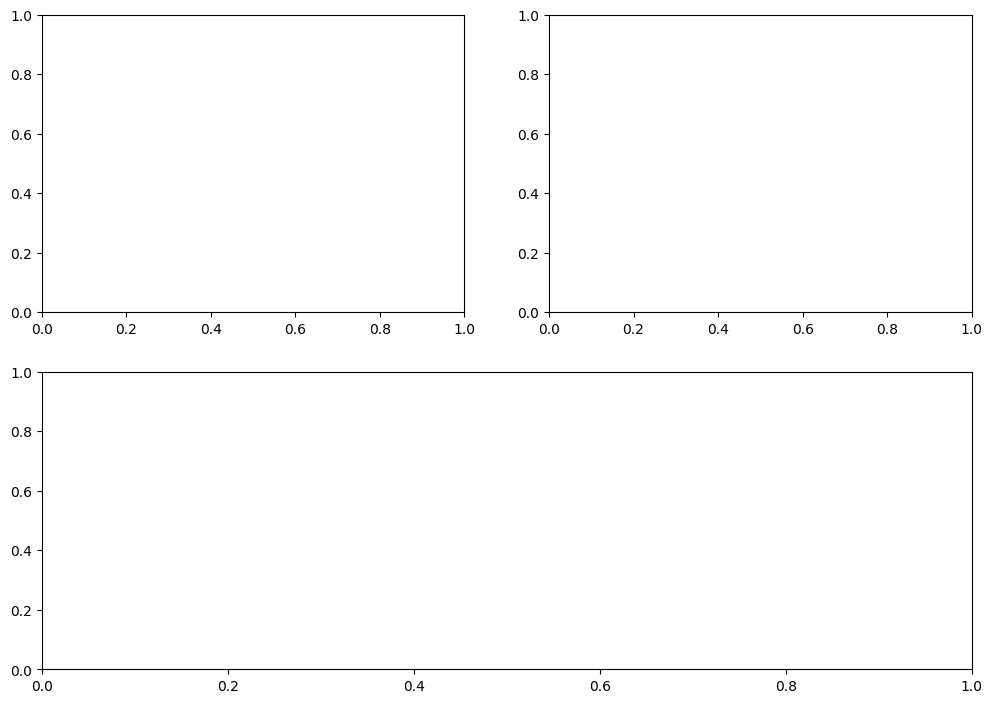

In [170]:
eda_helper.cat_univar_plots(train, "airline",k=8)

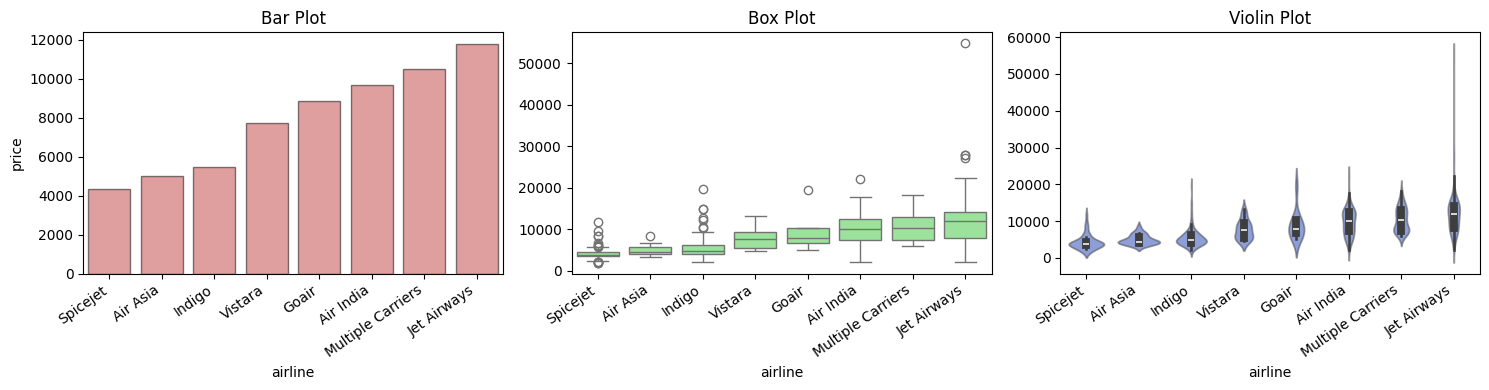

In [42]:
eda_helper.num_cat_bivar_plots(
	data=train,
	num_var="price",
	cat_var="airline"
)

In [43]:
eda_helper.num_cat_hyp_testing(train, "price", "airline")

- Significance Level   : 5.0%
- Null Hypothesis      : The groups have similar population mean
- Alternate Hypothesis : The groups don't have similar population mean
- Test Statistic       : 47.49151264655102
- p-value              : 3.795750562296659e-54
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and airline are associated to each other


- Significance Level   : 5.0%
- Null Hypothesis      : The groups have similar population median
- Alternate Hypothesis : The groups don't have similar population median
- Test Statistic       : 293.11244908395736
- p-value              : 1.7877035533071285e-59
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and airline are associated to each other


##### airline multivariate analysis

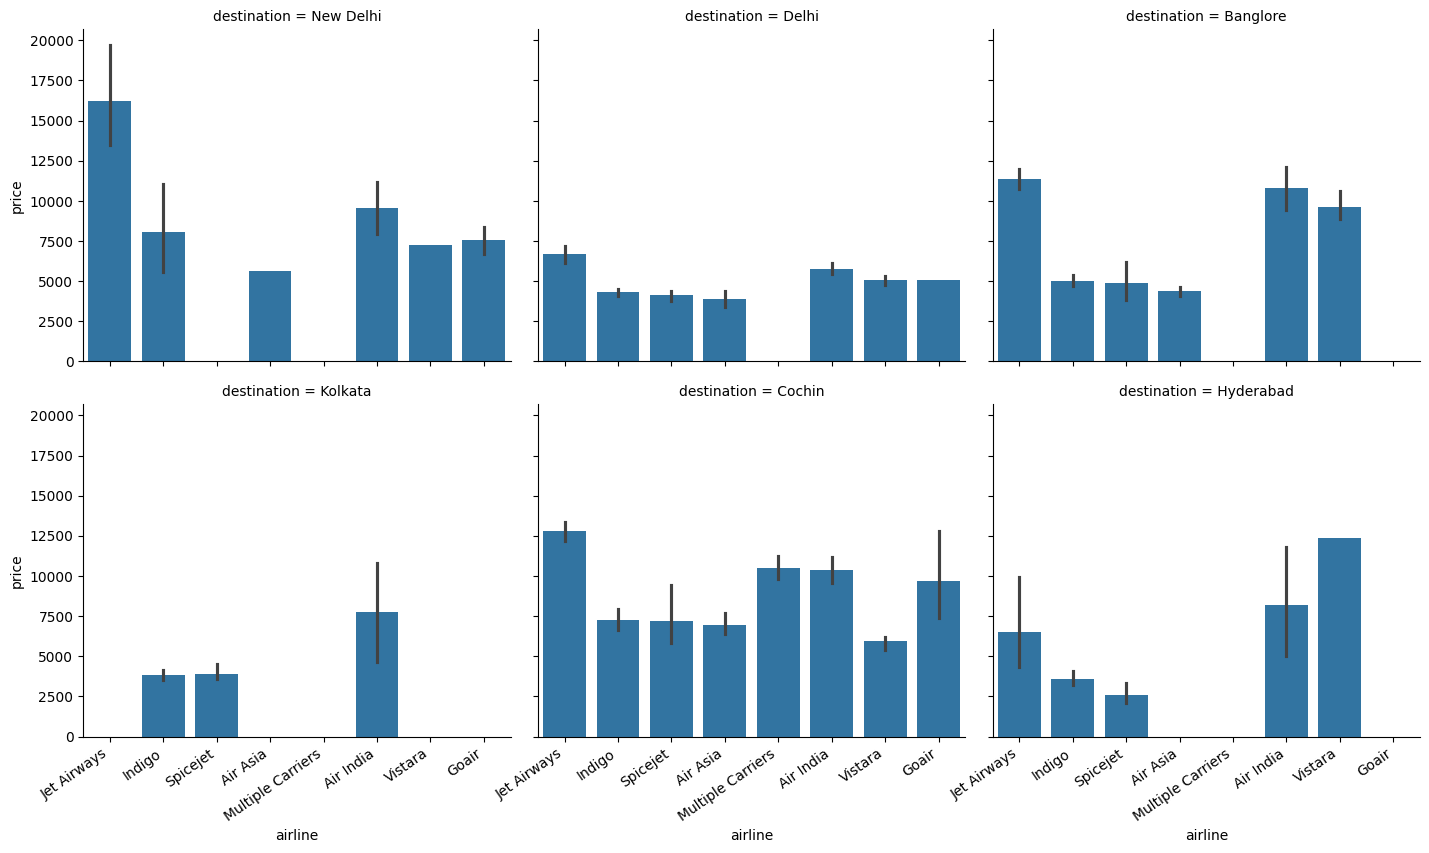

In [55]:
airline_grid = sns.FacetGrid( 
	data=train,
	col="destination",
	col_wrap=3,
	height=4,
	aspect=1.2,
	sharey=True
)

airline_grid.map(sns.barplot, "airline", "price", order=train.airline.unique())

for ax in airline_grid.axes[3:]:
	eda_helper.rotate_xlabels(ax)

### 8.2 date_of_journey

In [56]:
train.date_of_journey

0     2019-03-18
1     2019-06-09
2     2019-05-18
3     2019-05-18
4     2019-05-09
         ...    
635   2019-03-24
636   2019-06-06
637   2019-06-12
638   2019-03-21
639   2019-06-27
Name: date_of_journey, Length: 640, dtype: datetime64[ns]

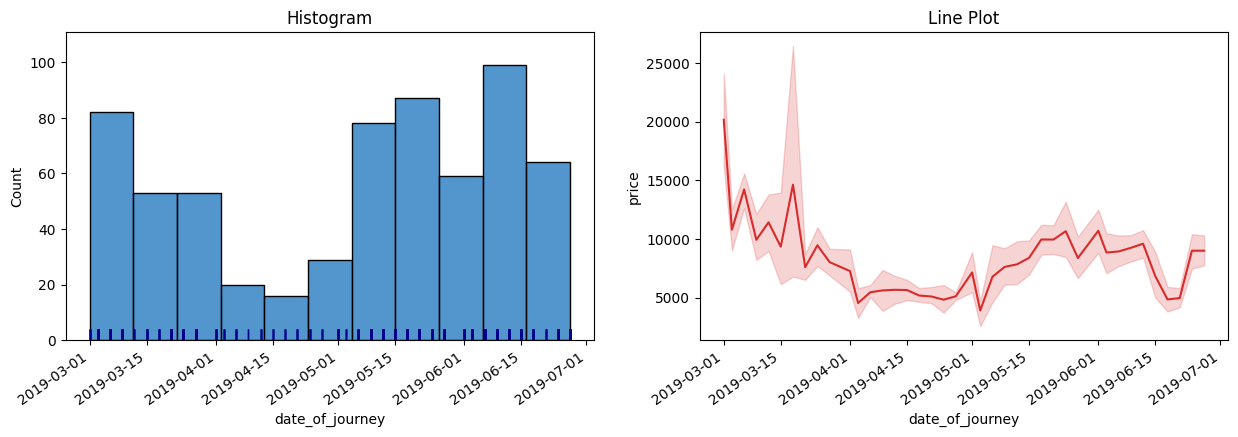

In [57]:
eda_helper.dt_univar_plots(
	data=train,
	var="date_of_journey",
	target="price"
)

In [89]:
train['date_of_journey'].dt.year.to_frame().value_counts()

date_of_journey
2019               640
Name: count, dtype: int64

In [104]:
train['date_of_journey'].dt.weekday.to_frame().value_counts()

date_of_journey
2                  136
3                  104
0                   99
5                   99
6                   96
1                   57
4                   49
Name: count, dtype: int64

<Axes: xlabel='month'>

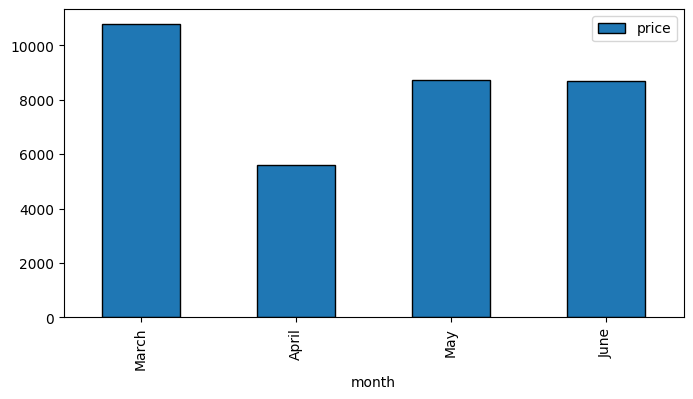

In [98]:
(
	train
	.groupby(pd.Grouper(key="date_of_journey", freq="M"))
	.price.mean()
	.to_frame()
	.set_axis(["March", "April", "May", "June"], axis=0)
	.rename_axis(index="month")
	.plot(
		kind="bar",
		figsize=(8, 4),
		edgecolor="black"
	)
)

# ax = plt.gca()
# eda_helper.rotate_xlabels(ax)

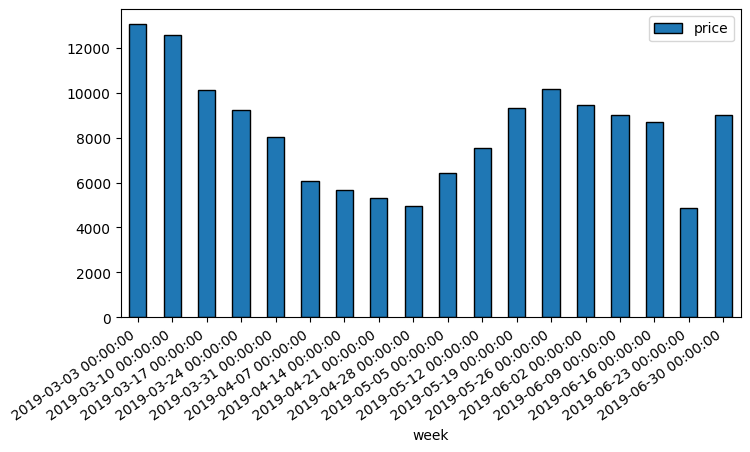

In [101]:
(
	train
	.groupby(pd.Grouper(key="date_of_journey", freq="W"))
	.price.mean()
	.to_frame()
	.rename_axis(index="week")
	.plot(
		kind="bar",
		figsize=(8, 4),
		edgecolor="black"
	)
)

ax = plt.gca()
eda_helper.rotate_xlabels(ax)

#### date_of_journey multivariant analysis

In [120]:
train.groupby([pd.Grouper(key="date_of_journey", freq="M"), "source"]).price.mean().to_frame()

price
date_of_journey source                
2019-03-31      Banglore  12687.983333
                Chennai    5917.000000
                Delhi     11027.597222
                Kolkata    8271.954545
                Mumbai     8099.647059
2019-04-30      Banglore   5258.129032
                Delhi      5689.363636
                Kolkata    6448.800000
                Mumbai     2050.000000
2019-05-31      Banglore   4929.812500
                Chennai    3699.875000
                Delhi     10708.123288
                Kolkata   10029.520000
                Mumbai     3186.666667
2019-06-30      Banglore   5840.240000
                Chennai    3912.000000
                Delhi     10390.618644
                Kolkata    8694.393939
                Mumbai     3592.235294

In [125]:
train.groupby([pd.Grouper(key="date_of_journey", freq="M"), "source"]).price.mean().unstack(fill_value=0).set_axis(["March", "April", "May", "June"], axis=0)

source,Banglore,Chennai,Delhi,Kolkata,Mumbai
March,12687.983333,5917.000,11027.597222,8271.954545,8099.647059
April,5258.129032,0.000,5689.363636,6448.800000,2050.000000
May,4929.812500,3699.875,10708.123288,10029.520000,3186.666667
June,5840.240000,3912.000,10390.618644,8694.393939,3592.235294


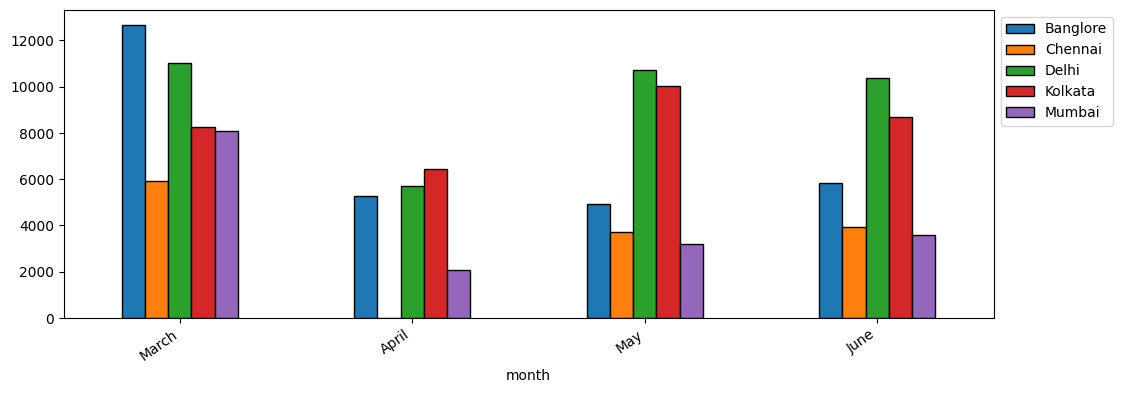

In [132]:
(
	train
	.groupby([pd.Grouper(key="date_of_journey", freq="M"), "source"])
	.price.mean()
	.unstack(fill_value=0)
	.set_axis(["March", "April", "May", "June"], axis=0)
	.rename_axis(index="month")
	.plot(
		kind="bar",
		figsize=(12, 4),
		edgecolor="black"
	)
)

ax = plt.gca()

ax.legend(
	loc="upper left",
	bbox_to_anchor=(1, 1)
)

eda_helper.rotate_xlabels(ax)

### 8.3 dep_time

In [133]:
train.dep_time

0     2024-06-04 16:55:00
1     2024-06-04 08:30:00
2     2024-06-04 04:40:00
3     2024-06-04 14:05:00
4     2024-06-04 17:10:00
              ...        
635   2024-06-04 21:20:00
636   2024-06-04 09:35:00
637   2024-06-04 20:55:00
638   2024-06-04 05:30:00
639   2024-06-04 18:55:00
Name: dep_time, Length: 640, dtype: datetime64[ns]

#### Univariate plots of dep_time

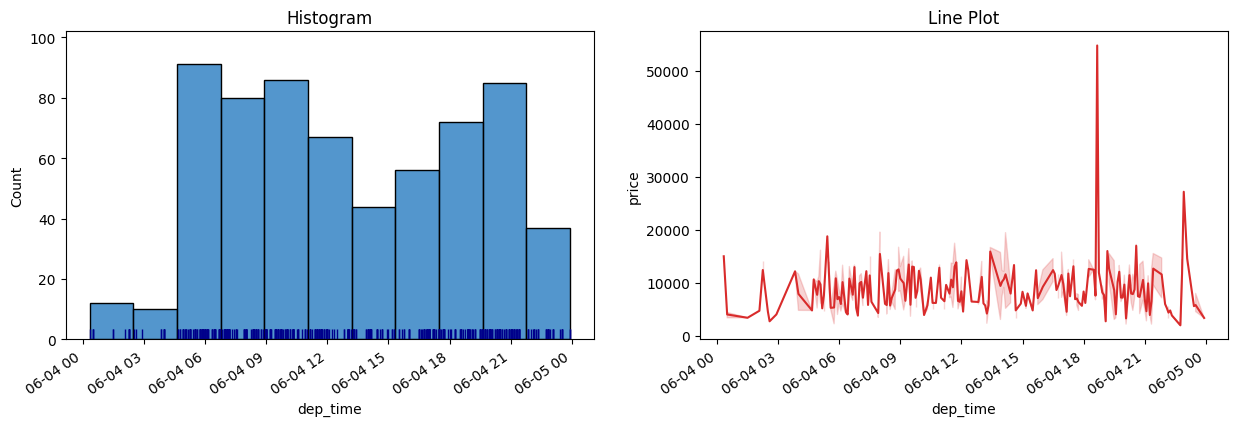

In [134]:
eda_helper.dt_univar_plots(train, "dep_time", "price")

In [140]:
display(train.dep_time.to_frame())
display(train.dep_time.to_frame().min())
display(train.dep_time.to_frame().max())

,dep_time
0,2024-06-04 16:55:00
1,2024-06-04 08:30:00
2,2024-06-04 04:40:00
3,2024-06-04 14:05:00
4,2024-06-04 17:10:00
...,...
635,2024-06-04 21:20:00
636,2024-06-04 09:35:00
637,2024-06-04 20:55:00
638,2024-06-04 05:30:00


dep_time   2024-06-04 00:20:00
dtype: datetime64[ns]

dep_time   2024-06-04 23:55:00
dtype: datetime64[ns]

In [148]:
(
    train.dep_time
    .dt.hour
    .pipe(lambda ser:ser)
    # on top of this we will apply 
)

0      16
1       8
2       4
3      14
4      17
       ..
635    21
636     9
637    20
638     5
639    18
Name: dep_time, Length: 640, dtype: int32

In [156]:
(
    train
    .assign(dep_time=lambda df_: (
    np.select([df_.dep_time.dt.hour.between(4,12,inclusive="left"),
               df_.dep_time.dt.hour.between(12,16,inclusive="left"),
               df_.dep_time.dt.hour.between(16,20,inclusive="left")],
               ["morning","afternoon","evening"],
               default="night")))
)

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-18,Banglore,New Delhi,evening,2024-06-04 23:00:00,365,1.0,No Info,13555
1,Indigo,2019-06-09,Banglore,Delhi,morning,2024-06-04 11:20:00,170,0.0,No Info,4823
2,Indigo,2019-05-18,Kolkata,Banglore,morning,2024-06-04 07:15:00,155,0.0,No Info,4804
3,Jet Airways,2019-05-18,Kolkata,Banglore,afternoon,2024-06-04 19:50:00,345,1.0,No Info,14781
4,Spicejet,2019-05-09,Kolkata,Banglore,evening,2024-06-04 19:40:00,150,0.0,No Info,3873
...,...,...,...,...,...,...,...,...,...,...
635,Indigo,2019-03-24,Banglore,New Delhi,night,2024-06-04 00:15:00,175,0.0,No Info,4777
636,Jet Airways,2019-06-06,Kolkata,Banglore,morning,2024-06-04 21:05:00,690,1.0,No Info,14151
637,Jet Airways,2019-06-12,Delhi,Cochin,night,2024-06-04 19:00:00,1325,1.0,In-flight meal not included,10262
638,Jet Airways,2019-03-21,Delhi,Cochin,morning,2024-06-04 18:50:00,2240,2.0,In-flight meal not included,9328


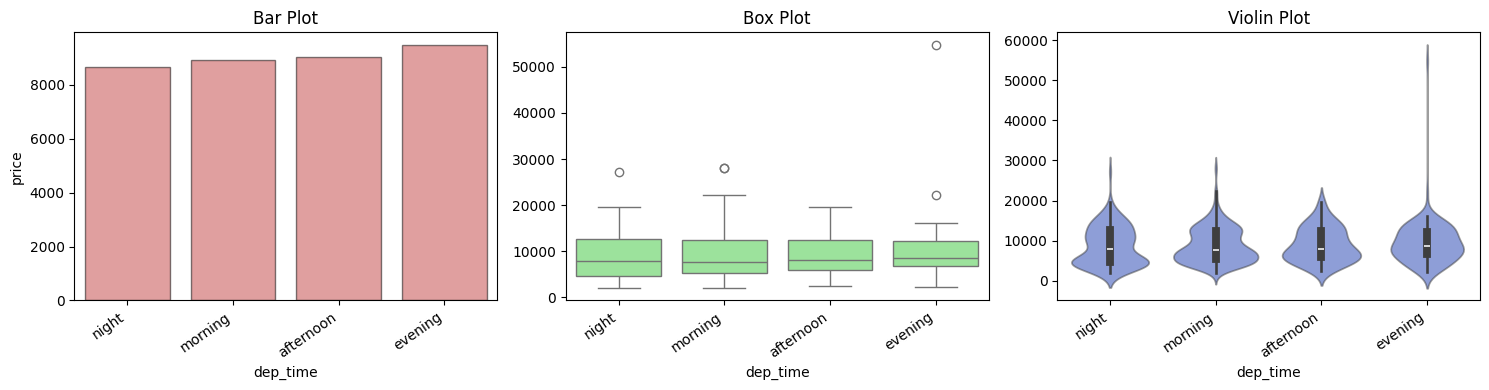

In [160]:
(
    train
    .assign(dep_time=lambda df: (
    np.select([df.dep_time.dt.hour.between(4,12,inclusive="left"),
               df.dep_time.dt.hour.between(12,16,inclusive="left"),
               df.dep_time.dt.hour.between(16,20,inclusive="left")],
               ["morning","afternoon","evening"],
               default="night")))
).pipe(eda_helper.num_cat_bivar_plots, "price", "dep_time")

### 8.4 duration

In [162]:
train.duration

0       365
1       170
2       155
3       345
4       150
       ... 
635     175
636     690
637    1325
638    2240
639     185
Name: duration, Length: 640, dtype: int64

In [163]:
eda_helper.num_summary(train, "duration")

0       365
1       170
2       155
3       345
4       150
       ... 
635     175
636     690
637    1325
638    2240
639     185
Name: duration, Length: 640, dtype: int64

Data Type      : int64
Missing Data   : 0 rows (0.00 %)
Available Data : 640 / 640 rows


,value
percentile,
0,75.0
5,90.0
10,144.5
25,170.0
50,470.0
75,920.0
90,1490.5
95,1610.0
99,1840.0


,value
mean,631.992188
trimmed mean (5%),598.151042
trimmed mean (10%),568.720703
median,470.000000


,value
var,263484.874743
std,513.307778
IQR,750.000000
mad,310.000000
coef_variance,0.812206


,value
skewness,0.880788
kurtosis,-0.258264


Significance Level   : 0.05
Null Hypothesis      : The data is normally distributed
Alternate Hypothesis : The data is not normally distributed
p-value              : 4.638966604000544e-22
Test Statistic       : 0.8772261738777161
- Since p-value is less than alpha (0.05), we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: We conclude that the data sample is not normally distributed


Significance Level   : 0.05
Null Hypothesis      : The data is normally distributed
Alternate Hypothesis : The data is not normally distributed
Critical Value       : 0.782
Test Statistic       : 26.902189350278377
- Since the Test-statistic is greater than Critical Value, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: We conclude that the data sample is not normally distributed


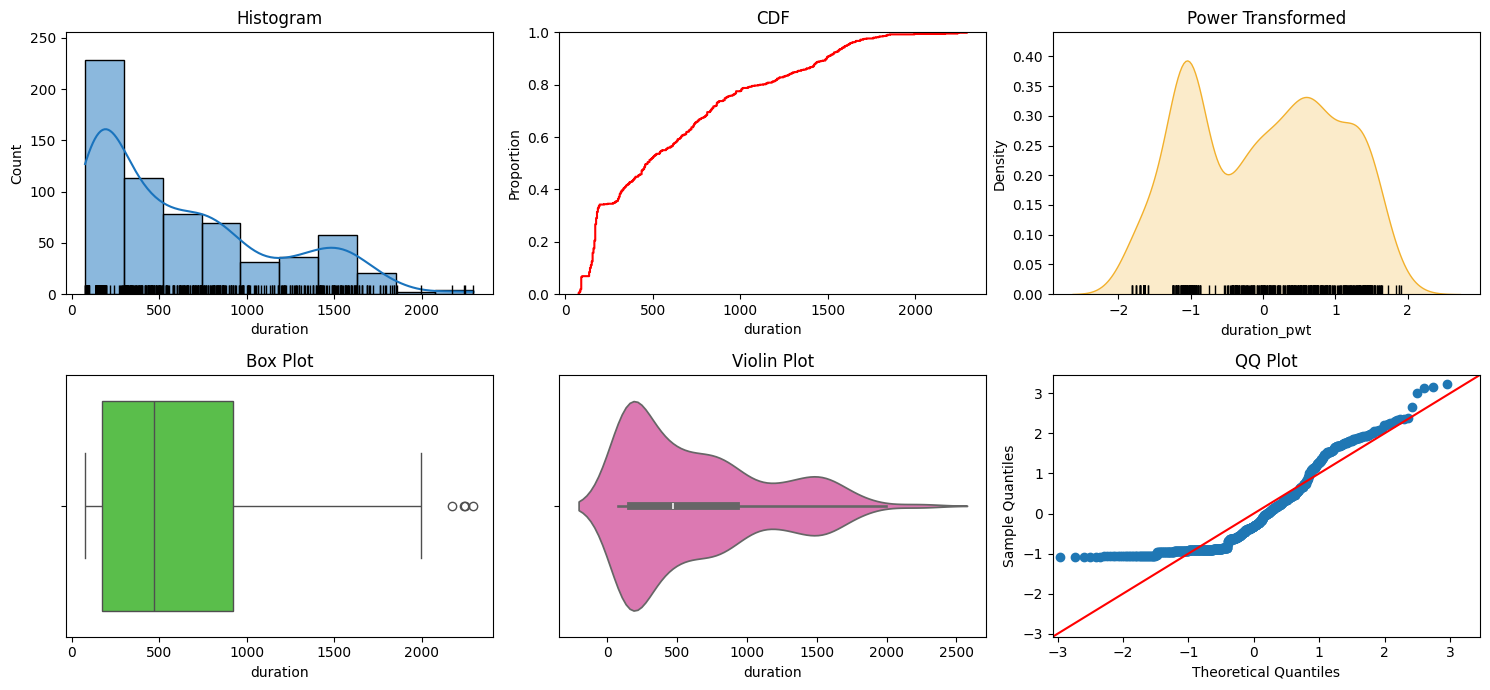

In [164]:
eda_helper.num_univar_plots(train, "duration")

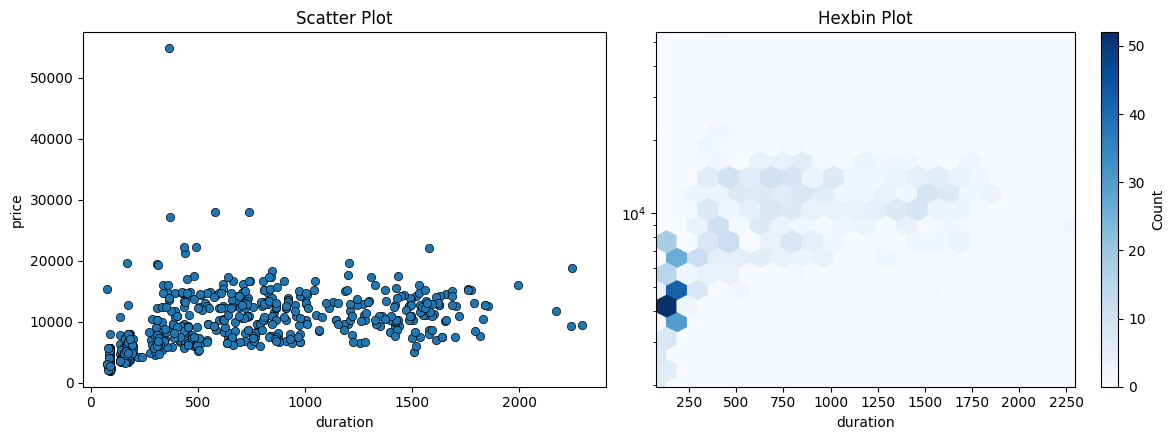

In [165]:
eda_helper.num_bivar_plots(
	train,
	"duration",
	"price",
	hexbin_kwargs=dict(
		yscale="log",
		gridsize=20,
		cmap="Blues"
	)
)

In [166]:
eda_helper.num_num_hyp_testing(train, "price", "duration")

- Significance Level   : 5.0%
- Null Hypothesis      : The samples are uncorrelated
- Alternate Hypothesis : The samples are correlated
- Test Statistic       : 0.5053893544348848
- p-value              : 8.586198973605852e-43
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and duration are correlated


- Significance Level   : 5.0%
- Null Hypothesis      : The samples are uncorrelated
- Alternate Hypothesis : The samples are correlated
- Test Statistic       : 0.7280047062770562
- p-value              : 1.0927950028165636e-106
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and duration are correlated


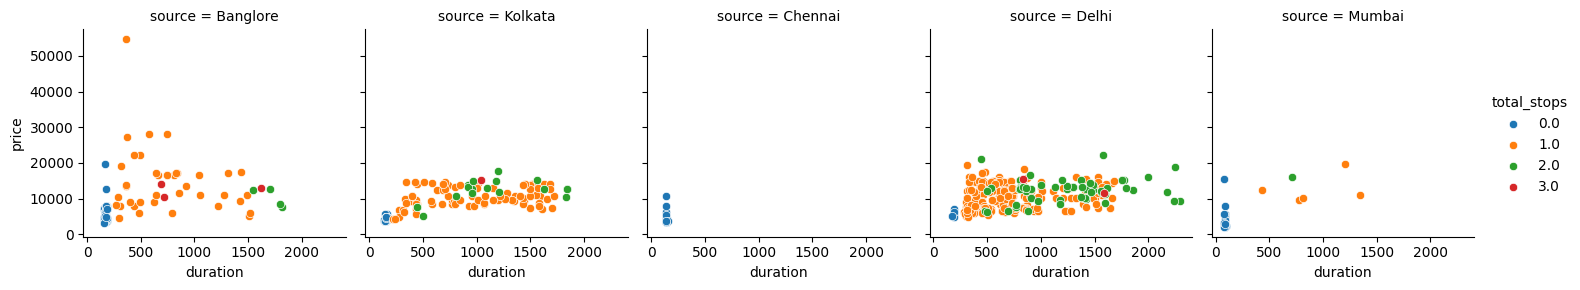

In [167]:
duration_grid = sns.FacetGrid(
	data=train,
	col="source",
	hue="total_stops",
	sharey=True
)

duration_grid.map(sns.scatterplot, "duration", "price")

duration_grid.add_legend()

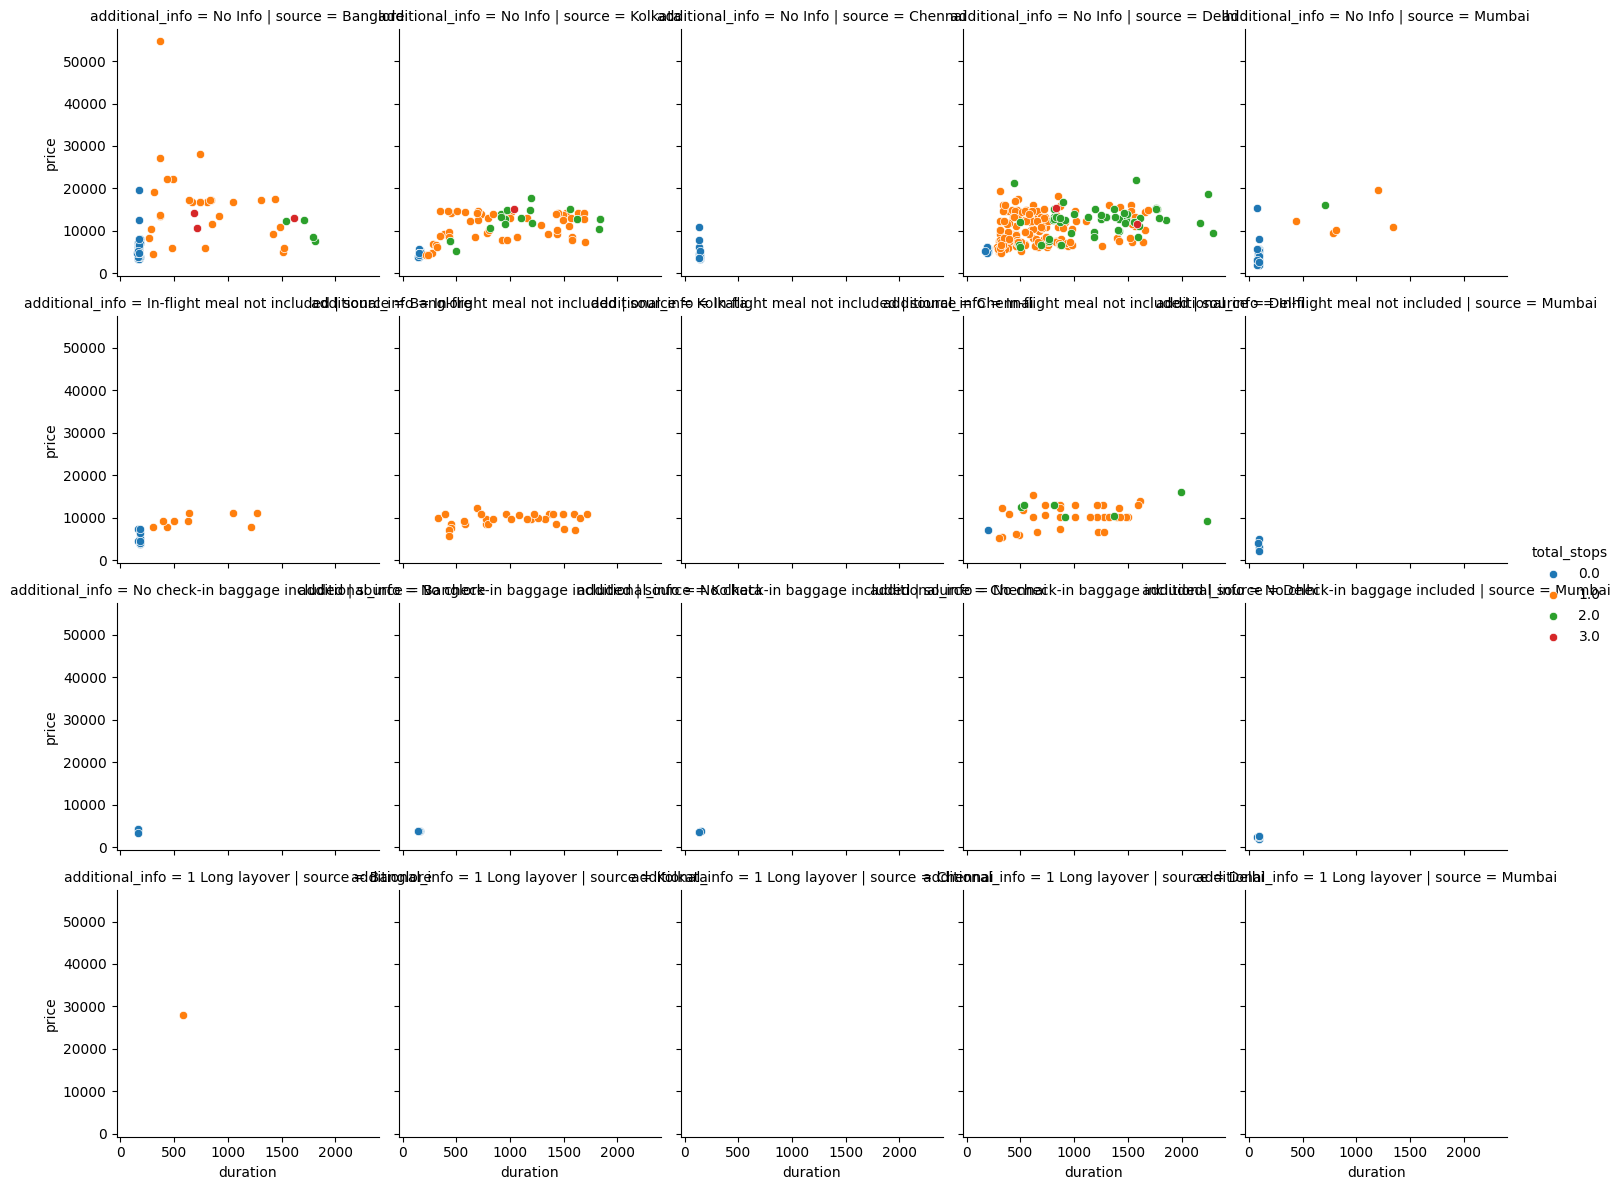

In [168]:
duration_grid = sns.FacetGrid(
	data=train,
	col="source",
	row="additional_info",
	hue="total_stops",
	sharey=True
)

duration_grid.map(sns.scatterplot, "duration", "price")

duration_grid.add_legend()


In [169]:
eda_helper.get_iqr_outliers(train, "duration")

Lower Limit : -955.0
Upper Limit : 2045.0


,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
161,Air India,2019-03-09,Delhi,Cochin,2024-06-04 07:05:00,2024-06-04 19:15:00,2170,2.0,No Info,11762
638,Jet Airways,2019-03-21,Delhi,Cochin,2024-06-04 05:30:00,2024-06-04 18:50:00,2240,2.0,In-flight meal not included,9328
170,Jet Airways,2019-03-03,Delhi,Cochin,2024-06-04 05:25:00,2024-06-04 18:50:00,2245,2.0,No Info,18799
363,Air India,2019-06-12,Delhi,Cochin,2024-06-04 05:00:00,2024-06-04 19:15:00,2295,2.0,No Info,9443


## 9. Automated EDA

In [ ]:
# from ydata_profiling import ProfileReport

In [ ]:
# report = ProfileReport(train)

In [ ]:
# report.to_file(output_file="output.html")